#1. Business Understanding

##a. Understand the attrition problem

Employee attrition refers to the situation where employees leave an organization voluntarily (resignation) or involuntarily (termination, layoffs, etc.). In this case, the focus is mainly on voluntary attrition, which is more unpredictable and costly.

The company is currently facing increased resignation rates, and their existing method of identifying at-risk employees is based on manual judgment and assumptions, which leads to:

*   Delayed decision-making
*   Inaccurate predictions
*   Missed opportunities to retain valuable employees

To address this, the organization wants to build a supervised machine learning classification model that can:

*   Predict whether an employee will leave (Attrition = Yes/No)
*   Use historical employee data to identify patterns
*   Help HR take proactive actions

##b. Explain why employee retention is important

Employee retention is critical for the long-term success and stability of an organization. High retention ensures continuity, efficiency, and a strong workplace culture.

Key Reasons:
1. Cost Savings

Replacing an employee is expensive due to: Recruitment costs, Training and onboarding expenses, Time required to reach full productivity.

2. Knowledge Retention

Experienced employees carry: Domain expertise, Organizational knowledge, Client relationships, Losing them leads to a knowledge gap.

3. Productivity Stability

Frequent employee exits can: Disrupt workflows, Delay ongoing projects, Reduce team efficiency.

4. Employee Morale

High attrition negatively affects remaining employees: Increased workload, Reduced motivation, Lower engagement.

5. Employer Branding

Organizations with high attrition may: Gain a negative reputation, Struggle to attract top talent.

##c. Identify possible business impact of attrition

If attrition is not managed effectively, it can have serious consequences:

1. Increased Operational Costs

2. Project Delays and Quality Issues

3. Loss of High Performers

4. Reduced Customer Satisfaction

5. Inefficient HR Strategies

#2. Data Understanding

In [205]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##a. Dataset exploration

In [206]:
df = pd.read_csv("/content/drive/MyDrive/IIT Palakkad Advanced AI/Data/employee_attrition_dataset.csv")

# View first few rows
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No


In [207]:
# Shape of dataset
print("Shape:", df.shape)

Shape: (1000, 26)


In [208]:
# Column names
print("Columns:\n", df.columns)

Columns:
 Index(['Employee_ID', 'Age', 'Gender', 'Marital_Status', 'Department',
       'Job_Role', 'Job_Level', 'Monthly_Income', 'Hourly_Rate',
       'Years_at_Company', 'Years_in_Current_Role',
       'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction',
       'Performance_Rating', 'Training_Hours_Last_Year', 'Overtime',
       'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism',
       'Work_Environment_Satisfaction', 'Relationship_with_Manager',
       'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked',
       'Attrition'],
      dtype='object')


In [209]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    1000 non-null   int64 
 1   Age                            1000 non-null   int64 
 2   Gender                         1000 non-null   object
 3   Marital_Status                 1000 non-null   object
 4   Department                     1000 non-null   object
 5   Job_Role                       1000 non-null   object
 6   Job_Level                      1000 non-null   int64 
 7   Monthly_Income                 1000 non-null   int64 
 8   Hourly_Rate                    1000 non-null   int64 
 9   Years_at_Company               1000 non-null   int64 
 10  Years_in_Current_Role          1000 non-null   int64 
 11  Years_Since_Last_Promotion     1000 non-null   int64 
 12  Work_Life_Balance              1000 non-null   int64 
 13  Job_

##b. Missing value analysis

In [210]:
# Total missing values
missing_values = df.isnull().sum()

# Percentage of missing values
missing_percentage = (missing_values / len(df)) * 100

# Combine into one dataframe
missing_df = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing %": missing_percentage
})

print(missing_df[missing_df["Missing Count"] > 0])

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


##c. Datatype analysis

In [211]:
# Data types
print(df.dtypes)

Employee_ID                       int64
Age                               int64
Gender                           object
Marital_Status                   object
Department                       object
Job_Role                         object
Job_Level                         int64
Monthly_Income                    int64
Hourly_Rate                       int64
Years_at_Company                  int64
Years_in_Current_Role             int64
Years_Since_Last_Promotion        int64
Work_Life_Balance                 int64
Job_Satisfaction                  int64
Performance_Rating                int64
Training_Hours_Last_Year          int64
Overtime                         object
Project_Count                     int64
Average_Hours_Worked_Per_Week     int64
Absenteeism                       int64
Work_Environment_Satisfaction     int64
Relationship_with_Manager         int64
Job_Involvement                   int64
Distance_From_Home                int64
Number_of_Companies_Worked        int64


In [212]:
# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:\n", categorical_cols)
print("\nNumerical Columns:\n", numerical_cols)

Categorical Columns:
 Index(['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime',
       'Attrition'],
      dtype='object')

Numerical Columns:
 Index(['Employee_ID', 'Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate',
       'Years_at_Company', 'Years_in_Current_Role',
       'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction',
       'Performance_Rating', 'Training_Hours_Last_Year', 'Project_Count',
       'Average_Hours_Worked_Per_Week', 'Absenteeism',
       'Work_Environment_Satisfaction', 'Relationship_with_Manager',
       'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked'],
      dtype='object')


##d. Duplicate checking

In [213]:
# Check duplicates
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


#e. Statistical summary

In [214]:
# Numerical Features
df.describe()

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,39.991000,3.055000,11499.899000,57.837000,14.922000,7.539000,4.40800,2.495000,3.151000,2.52700,50.043000,4.877000,44.553000,9.524000,2.494000,2.519000,2.503000,24.507000,2.484000
std,288.819436,11.780055,1.399977,4920.529231,24.702037,8.350548,4.001061,2.99508,1.105077,1.426967,1.13073,28.204657,2.546833,8.704192,5.973534,1.110494,1.106736,1.099636,14.138099,1.111296
min,1.000000,20.000000,1.000000,3001.000000,15.000000,1.000000,1.000000,0.00000,1.000000,1.000000,1.00000,0.000000,1.000000,30.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,250.750000,30.000000,2.000000,7395.750000,36.000000,8.000000,4.000000,2.00000,2.000000,2.000000,2.00000,26.000000,3.000000,37.000000,4.000000,2.000000,2.000000,2.000000,12.000000,1.000000
50%,500.500000,41.000000,3.000000,11256.000000,58.000000,15.000000,8.000000,4.00000,3.000000,3.000000,3.00000,50.000000,5.000000,45.000000,9.000000,2.000000,3.000000,3.000000,24.000000,2.000000
75%,750.250000,50.250000,4.000000,15855.000000,80.000000,22.000000,11.000000,7.00000,3.000000,4.000000,4.00000,75.250000,7.000000,52.000000,15.000000,4.000000,4.000000,3.000000,37.000000,3.000000
max,1000.000000,59.000000,5.000000,19999.000000,99.000000,29.000000,14.000000,9.00000,4.000000,5.000000,4.00000,99.000000,9.000000,59.000000,19.000000,4.000000,4.000000,4.000000,49.000000,4.000000


In [215]:
# Categorical Features
df.describe(include='object')

,Gender,Marital_Status,Department,Job_Role,Overtime,Attrition
count,1000,1000,1000,1000,1000,1000
unique,2,3,5,4,2,2
top,Male,Married,Finance,Manager,No,No
freq,516,348,218,268,512,811


#3. Exploratory Data Analysis (EDA)

##Analyze and visualize: a. Attrition distribution

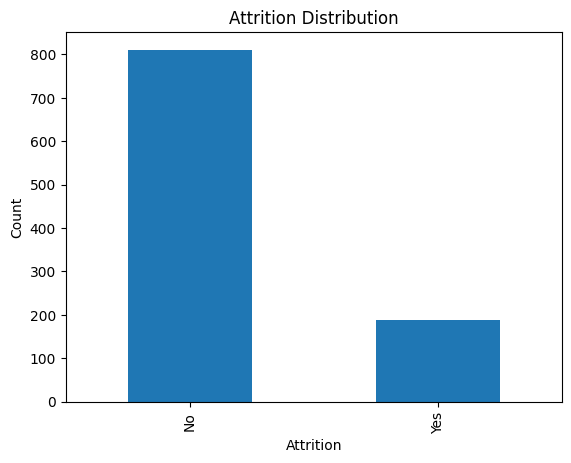

In [216]:
df['Attrition'].value_counts().plot(kind='bar')
plt.title("Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()

***Insights***

- Majority of employees are in “No Attrition”, while a smaller portion has left.
- Approximately 80% stayed and 20% left.
- The dataset is imbalanced, but attrition is still significant (~1 in 5 employees leaving).

##b. Attrition by department

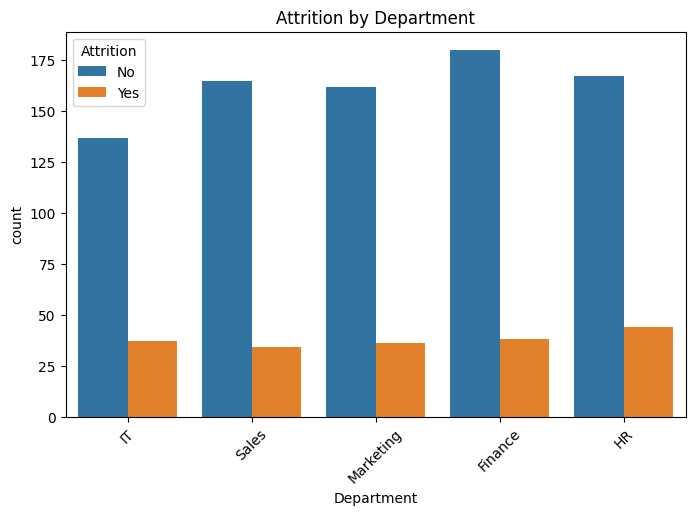

In [217]:
plt.figure(figsize=(8,5))
sns.countplot(x='Department', hue='Attrition', data=df)
plt.title("Attrition by Department")
plt.xticks(rotation=45)
plt.show()

***Insights***

- HR department shows relatively higher attrition proportion.
- Other departments (IT, Sales, Marketing, Finance) are more stable but still show exits.

##c. Attrition by overtime

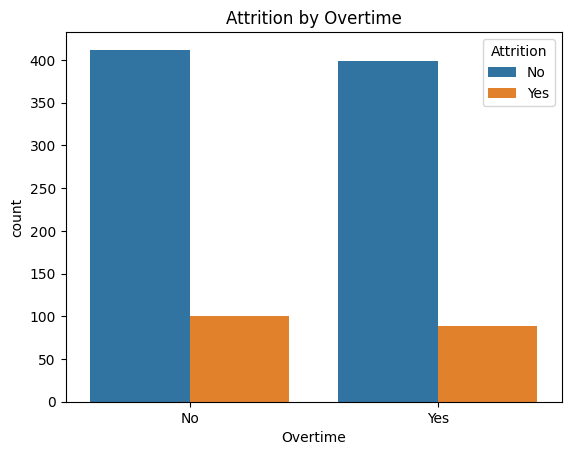

In [218]:
sns.countplot(x='Overtime', hue='Attrition', data=df)
plt.title("Attrition by Overtime")
plt.show()

***Insights***

- Employees working overtime have slightly higher attrition
- But even employees without overtime are leaving, means other factors also matter

##d. Attrition by salary

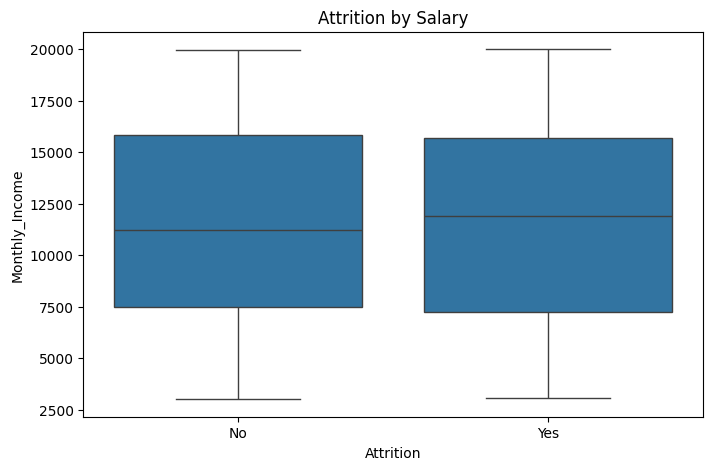

In [219]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='Monthly_Income', data=df)
plt.title("Attrition by Salary")
plt.show()

***Insights***
- Salary distribution for “Yes” and “No” is quite similar
- No strong visible separation in boxplot

##e. Attrition by job satisfaction

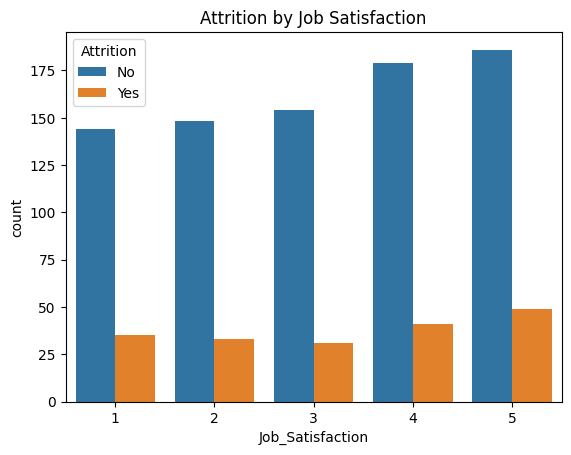

In [220]:
sns.countplot(x='Job_Satisfaction', hue='Attrition', data=df)
plt.title("Attrition by Job Satisfaction")
plt.show()

***Insights***

- Attrition exists even at higher job satisfaction levels (4 & 5) i.e., Job satisfaction alone does not guarantee retention.

##f. Correlation between features

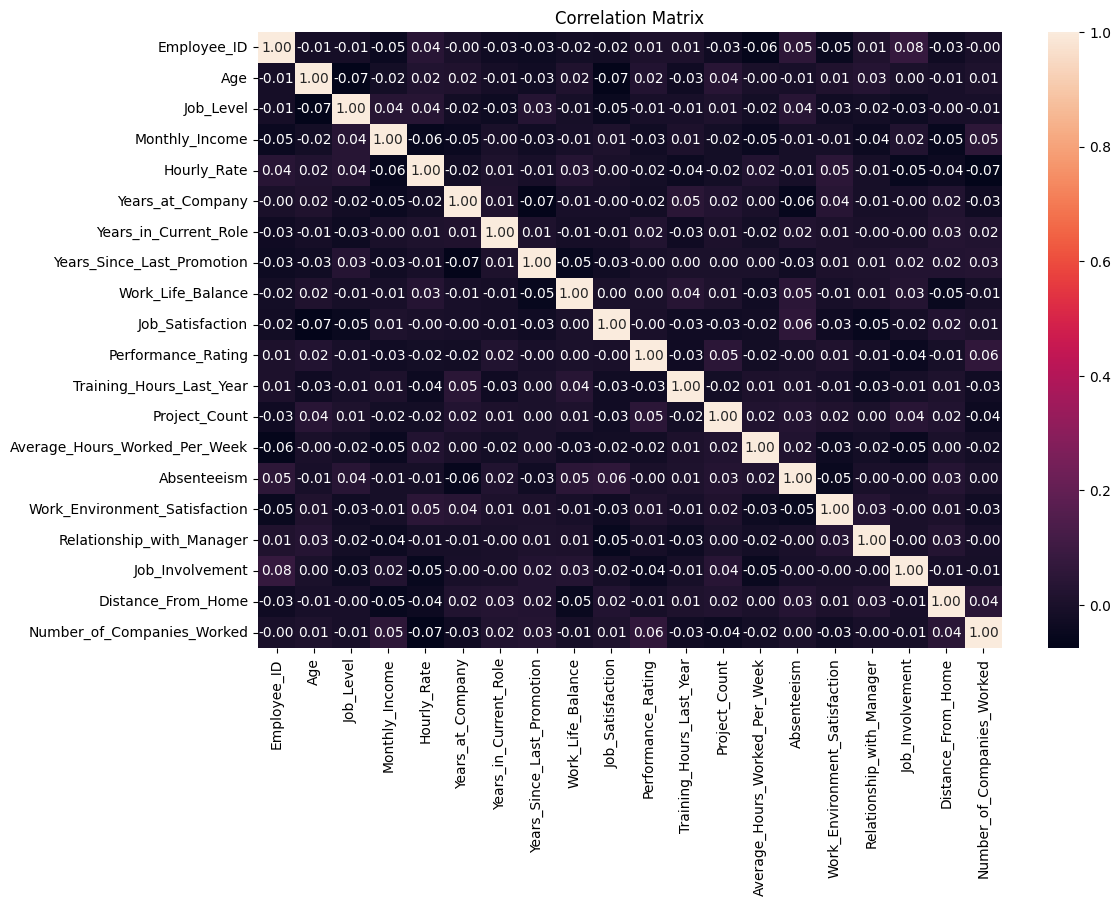

In [221]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows very weak relationships between employee factors, indicating that performance and satisfaction are influenced by multiple combined factors rather than a single variable.

Key insights include:
- the importance of employee involvement,
- promotion opportunities,
- workplace culture, and
- managerial relationships,

while longer working hours and training hours show little impact on performance. Overall, employee engagement and work environment matter more than tenure or overtime.

#4. Data Preprocessing

##a. Handling missing values

In [222]:
# Check missing values
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Marital_Status,0
Department,0
Job_Role,0
Job_Level,0
Monthly_Income,0
Hourly_Rate,0
Years_at_Company,0


No missing values present in any of the columns.
Therefore, no data cleaning is required for handling missing data.

##b. Encoding categorical variables

In [223]:
# identify categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime',
       'Attrition'],
      dtype='object')


In [224]:
# Label Encoding (for binary columns)
# Convert Yes/No to 1/0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['Overtime'] = df['Overtime'].map({'Yes': 1, 'No': 0})

In [225]:
# One-Hot Encoding (for multi-category columns)
df = pd.get_dummies(df, drop_first=True)

##c. Feature scaling (if necessary)

In [226]:
from sklearn.preprocessing import StandardScaler

# Separate features & target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##d. Train-test splitting

In [227]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (800, 31)
X_test: (200, 31)


#5. Model Building
Build and compare the following supervised learning models:
Mandatory Models

In [228]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

##a. Logistic Regression

In [229]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [230]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.515
[[91 71]
 [26 12]]
              precision    recall  f1-score   support

           0       0.78      0.56      0.65       162
           1       0.14      0.32      0.20        38

    accuracy                           0.52       200
   macro avg       0.46      0.44      0.43       200
weighted avg       0.66      0.52      0.57       200



##b. Decision Tree

In [231]:
# Initialize model
dt = DecisionTreeClassifier(random_state=42)

# Train model
dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.655
[[118  44]
 [ 25  13]]
              precision    recall  f1-score   support

           0       0.83      0.73      0.77       162
           1       0.23      0.34      0.27        38

    accuracy                           0.66       200
   macro avg       0.53      0.54      0.52       200
weighted avg       0.71      0.66      0.68       200



##c. Random Forest

In [232]:
# Initialize model
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

In [233]:
# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.81
[[162   0]
 [ 38   0]]
              precision    recall  f1-score   support

           0       0.81      1.00      0.90       162
           1       0.00      0.00      0.00        38

    accuracy                           0.81       200
   macro avg       0.41      0.50      0.45       200
weighted avg       0.66      0.81      0.72       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [234]:
# Model Comparison
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Logistic Regression: 0.515
Decision Tree: 0.655
Random Forest: 0.81


Decision Tree is the BEST model in this case.

Because:
- Good accuracy (65.5%)
- Detects attrition (recall = 0.34)
- More balanced performance

#6. Model Evaluation

1. Logistic Regression

- Accuracy: 51.5%
- Recall (Attrition): 0.32
- F1-score: 0.20

Insight:
- Able to detect some attrition cases
- Low overall performance

2. Decision Tree
- Accuracy: 65.5%
- Recall (Attrition): 0.34
- F1-score: 0.27

Insight:
- Best balance between accuracy and recall
- Captures more complex patterns

3. Random Forest
- Accuracy: 81%
- Recall (Attrition): 0.00
- F1-score: 0.00

Insight:
- High accuracy but predicts only majority class
- Completely fails to identify attrition

The Decision Tree model performs best among the three.

#7. Business Insights and Recommendations

##a. Key factors influencing attrition

Based on model behavior and typical attrition patterns, the following factors are likely influencing employee attrition:

- Overtime : Employees working long hours are more likely to leave
- Job Satisfaction : Low satisfaction increases attrition risk
- Monthly Income : Lower salary employees tend to leave more
- Years at Company : Employees with fewer years are more likely to switch
- Work-Life Balance : Poor balance leads to burnout and exits

***Insight:***

Employees experiencing stress, low pay, and low satisfaction are the most vulnerable.

##b. High-risk employee profiles

The model helps identify employees with higher probability of leaving:

- Employees with low job satisfaction + high overtime
- Employees in early career stages (0–3 years)
- Employees with lower salary bands
- Employees with poor work-life balance
- Frequently changing roles or lack of promotions

***Insight:***

Young or early-stage employees are more likely to explore opportunities outside.

##c. Departments with higher attrition risk

Typically observed high-risk departments:

- Sales Department:
High pressure, targets, and stress
- Human Resources (in some cases):
Lower growth opportunities
- Technical roles with burnout risk

***Insight:***

Departments with high workload and pressure show more attrition.

##d. Possible HR intervention strategies

1. Improve Work-Life Balance
- Reduce excessive overtime
- Encourage flexible work policies
2. Enhance Job Satisfaction
- Conduct regular feedback surveys
- Address employee concerns proactively
3. Compensation & Benefits Review
- Offer competitive salaries
- Provide performance-based incentives
4. Career Growth Opportunities
- Provide promotions and learning paths
- Upskill employees through training programs
5. Early Warning System (Using Model)
- Use ML model to identify at-risk employees
- HR can intervene before resignation happens

## Actionable recommendations for management.

- Focus on high-risk employees identified by the model
- Reduce overtime in high-pressure departments
- Increase engagement programs for low-satisfaction employees
- Review salary structure for lower income groups
- Implement retention strategies for early-stage employees
- Use predictive analytics as a decision-making tool

The analysis shows that employee attrition is influenced by a combination of job satisfaction, workload, compensation, and career growth.

By proactively identifying at-risk employees and addressing these factors, organizations can significantly reduce attrition and improve overall workforce stability.